# Clinical eCRF Data Validation & Data Quality Analysis

**Prepared by:** Clinical Data Coordinator (Portfolio Project)
**Purpose:** Demonstrate a beginner-to-intermediate level, real-world style
Clinical Data Management (CDM) workflow using a synthetic clinical trial dataset.

## 1. Introduction

In clinical trials, data is captured on **electronic Case Report Forms (eCRFs)**
at each patient visit. Before this data can be used for statistical analysis or
regulatory submission, a Clinical Data Coordinator / Clinical Data Analyst must
check it for **completeness, accuracy, and consistency**. This process is called
**Clinical Data Validation**.

This notebook walks through a simulated eCRF dataset for a fictional trial with:

- **300 subjects**
- **5 investigational sites** (SITE001–SITE005)
- **3 scheduled visits** (Screening, Baseline, Week 4)

We will:

1. Load the raw and cleaned datasets
2. Explore the data structure
3. Identify missing values, duplicates, and out-of-range values
4. Analyze the discrepancy query log
5. Visualize data quality trends
6. Summarize findings in a final data quality report with recommendations

> **Note:** All data in this notebook is 100% synthetic and was generated for
> educational/portfolio purposes only. No real patient data was used.

## 2. Load Dataset

We start by importing the libraries we need. In line with common clinical data
analyst practice, we keep our toolkit simple: **pandas** for data handling,
**numpy** for numeric operations, and **matplotlib** for charts.

We then load three files:
- `raw_ecrf_data.csv` — the raw data as entered by sites (contains errors)
- `cleaned_ecrf_data.csv` — the validated/cleaned dataset
- `discrepancy_query_log.csv` — the log of data queries raised during review

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings so tables are easy to read
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 150)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the raw eCRF dataset (as captured at site, before cleaning)
raw_df = pd.read_csv("../data/raw_ecrf_data.csv")

# Load the cleaned eCRF dataset (after data management review)
clean_df = pd.read_csv("../data/cleaned_ecrf_data.csv")

# Load the discrepancy query log
query_df = pd.read_csv("../data/discrepancy_query_log.csv")

print("Raw data shape:", raw_df.shape)
print("Cleaned data shape:", clean_df.shape)
print("Query log shape:", query_df.shape)

Raw data shape: (906, 21)
Cleaned data shape: (882, 21)
Query log shape: (89, 13)


## 3. Dataset Overview

Before doing any validation, we always get familiar with the dataset:
its shape, column names, first few rows, data types, and summary statistics.
This is a standard first step for any Clinical Data Analyst.

In [3]:
# Shape of the raw dataset: (rows, columns)
print("Raw dataset shape (rows, columns):", raw_df.shape)

print()
print("Columns in raw dataset:")
for col in raw_df.columns:
    print("-", col)

Raw dataset shape (rows, columns): (906, 21)

Columns in raw dataset:
- Site_ID
- Subject_ID
- Visit
- Visit_Date
- Informed_Consent_Date
- Age
- Sex
- Height_cm
- Weight_kg
- BMI
- Heart_Rate_bpm
- Respiratory_Rate
- Temperature_C
- Systolic_BP_mmHg
- Diastolic_BP_mmHg
- Lab_Status
- ECG_Status
- Adverse_Event
- Concomitant_Medication
- Investigator_Name
- Data_Entry_Date


In [4]:
# Preview the first 5 rows of the raw dataset
raw_df.head()

,Site_ID,Subject_ID,Visit,Visit_Date,Informed_Consent_Date,Age,Sex,Height_cm,Weight_kg,BMI,Heart_Rate_bpm,Respiratory_Rate,Temperature_C,Systolic_BP_mmHg,Diastolic_BP_mmHg,Lab_Status,ECG_Status,Adverse_Event,Concomitant_Medication,Investigator_Name,Data_Entry_Date
0,SITE005,SUBJ0135,Baseline,2024-02-22,2024-01-18,53.0,Female,162.0,81.4,31.0,81,12,36.7,121,76,Normal,Abnormal,Dizziness,Paracetamol,Dr. E. Costa,2024-02-27
1,SITE003,SUBJ0288,Baseline,2024-03-05,2024-02-11,49.0,Female,155.1,NaN,29.0,65,15,36.3,138,67,Not Done,Normal,NaN,Paracetamol,Dr. C. Patel,2024-03-08
2,SITE002,SUBJ0197,Week 4,2024-03-27,NaN,67.0,Female,167.2,70.9,25.4,78,19,36.3,117,71,Not Done,Not Done,Dizziness,NaN,Dr. B. Nguyen,2024-03-27
3,SITE001,SUBJ0081,Week 4,2024-02-03,2024-01-03,42.0,Female,178.7,67.3,21.1,106,16,36.5,116,87,Abnormal,Normal,Mild Headache,NaN,Dr. A. Sharma,2024-02-05
4,SITE001,SUBJ0146,Week 4,2024-03-13,2024-02-01,44.0,Male,160.8,80.3,31.1,93,15,37.1,123,88,Not Done,Abnormal,Mild Headache,NaN,Dr. A. Sharma,2024-03-15


In [5]:
# Data types and non-null counts for each column
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Site_ID                 906 non-null    str    
 1   Subject_ID              900 non-null    str    
 2   Visit                   906 non-null    str    
 3   Visit_Date              900 non-null    str    
 4   Informed_Consent_Date   900 non-null    str    
 5   Age                     900 non-null    float64
 6   Sex                     906 non-null    str    
 7   Height_cm               906 non-null    float64
 8   Weight_kg               900 non-null    float64
 9   BMI                     906 non-null    float64
 10  Heart_Rate_bpm          906 non-null    int64  
 11  Respiratory_Rate        906 non-null    int64  
 12  Temperature_C           906 non-null    float64
 13  Systolic_BP_mmHg        906 non-null    int64  
 14  Diastolic_BP_mmHg       906 non-null    int64  
 15  

In [6]:
# Summary statistics for numeric columns (vital signs, age, etc.)
raw_df.describe()

,Age,Height_cm,Weight_kg,BMI,Heart_Rate_bpm,Respiratory_Rate,Temperature_C,Systolic_BP_mmHg,Diastolic_BP_mmHg
count,900.000000,906.000000,900.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000
mean,45.425556,165.426821,69.776778,25.770861,75.443709,15.452539,36.792274,121.857616,77.484547
std,11.326287,10.179459,14.817006,6.260439,15.541555,3.020457,0.686786,14.253298,7.845489
min,18.000000,136.000000,21.400000,7.900000,16.000000,6.000000,30.200000,85.000000,52.000000
25%,37.000000,158.900000,60.100000,21.600000,68.000000,14.000000,36.500000,113.000000,72.000000
50%,46.000000,164.900000,69.700000,25.400000,75.000000,15.000000,36.800000,122.000000,78.000000
75%,53.000000,172.225000,80.025000,29.400000,82.000000,17.000000,37.100000,129.000000,83.000000
max,75.000000,194.900000,117.300000,54.800000,219.000000,25.000000,42.800000,235.000000,100.000000


## 4. Missing Value Analysis

Missing data is one of the most common data quality issues in clinical trials.
Here we count missing values per column in the raw dataset and calculate the
percentage of missing data, which helps prioritize which fields need the most
data management attention.

In [7]:
# Count missing values per column in the raw dataset
missing_counts = raw_df.isnull().sum()
missing_percent = round((missing_counts / len(raw_df)) * 100, 2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_percent
})

# Only show columns that actually have missing values
missing_summary = missing_summary[missing_summary["Missing_Count"] > 0]
missing_summary = missing_summary.sort_values("Missing_Count", ascending=False)

# Total number of missing values across the entire raw dataset
total_missing = raw_df.isnull().sum().sum()
print("Total missing values in raw dataset:", total_missing)
print("Percent of total cells missing:", round((total_missing / (raw_df.shape[0]*raw_df.shape[1]))*100, 2), "%")
print()
missing_summary

Total missing values in raw dataset: 779
Percent of total cells missing: 4.09 %



,Missing_Count,Missing_Percent
Adverse_Event,391,43.16
Concomitant_Medication,353,38.96
Subject_ID,6,0.66
Visit_Date,6,0.66
Age,6,0.66
Informed_Consent_Date,6,0.66
Weight_kg,6,0.66
Investigator_Name,5,0.55


## 5. Duplicate Analysis

Duplicate records (e.g., the same subject and visit entered twice) can distort
statistical results. We check for fully duplicated rows and for duplicate
Subject IDs, which is a common eCRF entry error.

In [8]:
# Check for fully duplicated rows in the raw dataset
duplicate_rows = raw_df[raw_df.duplicated()]
print("Number of fully duplicated rows:", len(duplicate_rows))
duplicate_rows.head()

Number of fully duplicated rows: 6


,Site_ID,Subject_ID,Visit,Visit_Date,Informed_Consent_Date,Age,Sex,Height_cm,Weight_kg,BMI,Heart_Rate_bpm,Respiratory_Rate,Temperature_C,Systolic_BP_mmHg,Diastolic_BP_mmHg,Lab_Status,ECG_Status,Adverse_Event,Concomitant_Medication,Investigator_Name,Data_Entry_Date
163,SITE001,SUBJ0261,Screening,2024-01-12,2024-01-05,41.0,Female,159.9,72.2,28.2,82,23,37.1,135,73,Not Done,Not Done,Nausea,Antihistamine,Dr. A. Sharma,2024-01-17
413,SITE001,SUBJ0176,Screening,2024-01-26,2024-01-10,59.0,Male,158.7,70.7,28.1,75,14,36.3,125,77,Normal,Not Done,NaN,Paracetamol,Dr. A. Sharma,2024-01-28
572,SITE002,SUBJ0292,Baseline,2024-03-09,2024-02-03,45.0,Female,167.7,72.4,25.7,88,15,36.8,108,84,Abnormal,Normal,Mild Headache,Antihistamine,Dr. B. Nguyen,2024-03-13
658,SITE002,SUBJ0287,Week 4,2024-03-24,2024-02-12,39.0,Female,182.2,61.4,18.5,72,17,37.4,114,78,Not Done,Normal,NaN,NaN,Dr. B. Nguyen,2024-03-25
834,SITE004,SUBJ0294,Baseline,2024-01-28,2024-01-08,59.0,Male,177.3,60.2,19.2,71,14,36.9,126,70,Normal,Not Done,NaN,Antihistamine,Dr. D. Fernandes,2024-01-30


In [9]:
# Check for duplicate Subject IDs (a subject ID should ideally be unique per subject,
# but can appear more than once here due to data entry errors)
subject_counts = raw_df["Subject_ID"].value_counts()
duplicate_subjects = subject_counts[subject_counts > 3]  # more than 3 visit rows is unusual
print("Subject IDs appearing more than expected number of times:")
duplicate_subjects

Subject IDs appearing more than expected number of times:


Subject_ID
SUBJ0001    6
SUBJ0002    5
SUBJ0261    4
SUBJ0003    4
SUBJ0176    4
SUBJ0287    4
SUBJ0292    4
Name: count, dtype: int64

## 6. Query Log Analysis

When a Clinical Data Coordinator finds an issue in the eCRF, a **data query** is
raised and sent to the site for clarification. Here we explore the structure
and status distribution of our discrepancy query log.

In [10]:
# Preview the query log
query_df.head()

,Query_ID,Site_ID,Subject_ID,Visit,Form_Name,Field_Name,Error_Type,Error_Description,Query_Status,Priority,Action_Required,Query_Date,Resolution_Date
0,Q0001,SITE003,SUBJ0288,Baseline,ECG,Weight_kg,Missing Data,Weight not recorded at visit,Closed,High,None - Resolved,2024-02-19,2024-02-27
1,Q0002,SITE002,SUBJ0197,Week 4,Demographics,Informed_Consent_Date,Missing Data,Informed consent date not entered,Answered,High,Awaiting DM review,2024-03-13,NaN
2,Q0003,SITE005,SUBJ0290,Screening,Demographics,Heart_Rate_bpm,Range Check Failure,Heart rate outside protocol-defined normal range,Open,Medium,Pending site response,2024-06-22,NaN
3,Q0004,SITE001,SUBJ0261,Week 4,ECG,Heart_Rate_bpm,Range Check Failure,Heart rate outside protocol-defined normal range,Open,High,Pending site response,2024-02-15,NaN
4,Q0005,SITE005,SUBJ0285,Baseline,Adverse Events,Visit_Date,Logic Check Failure,Visit date recorded before informed consent date,Answered,High,Awaiting DM review,2024-04-21,NaN


In [11]:
# Count of queries by status (Open, Answered, Closed, Cancelled)
query_status_counts = query_df["Query_Status"].value_counts()
print("Queries by Status:")
print(query_status_counts)

# Count of queries by error type
error_type_counts = query_df["Error_Type"].value_counts()
print()
print("Queries by Error Type:")
print(error_type_counts)

# Count of queries by priority level
priority_counts = query_df["Priority"].value_counts()
print()
print("Queries by Priority:")
print(priority_counts)

Queries by Status:
Query_Status
Open         35
Closed       24
Answered     19
Cancelled    11
Name: count, dtype: int64

Queries by Error Type:
Error_Type
Missing Data           35
Range Check Failure    28
Logic Check Failure    12
Duplicate Record        8
Invalid Value           6
Name: count, dtype: int64

Queries by Priority:
Priority
Medium    34
High      33
Low       22
Name: count, dtype: int64


## 7. Subject Level Analysis

Next we look at data quality from the **subject** perspective — which subjects
have the most queries raised against them. This helps identify subjects whose
data may need extra attention before database lock.

In [12]:
# Number of queries per subject, sorted from highest to lowest
subject_query_counts = query_df["Subject_ID"].value_counts().head(15)

# Average number of queries per subject across the whole trial
avg_queries_per_subject = round(len(query_df) / raw_df["Subject_ID"].nunique(), 2)
print("Average queries per subject:", avg_queries_per_subject)
print()
print("Top subjects by query count:")
subject_query_counts

Average queries per subject: 0.3

Top subjects by query count:


Subject_ID
UNKNOWN     6
SUBJ0197    2
SUBJ0222    2
SUBJ0299    2
SUBJ0105    2
SUBJ0136    2
SUBJ0108    2
SUBJ0288    1
SUBJ0290    1
SUBJ0261    1
SUBJ0285    1
SUBJ0220    1
SUBJ0283    1
SUBJ0289    1
SUBJ0216    1
Name: count, dtype: int64

## 8. Site Level Analysis

Data quality often varies by investigational site due to differences in staff
training and experience. Here we compare the number of queries raised per site,
which is a key metric reviewed in CDM site performance meetings.

In [13]:
# Number of queries raised per site
site_query_counts = query_df["Site_ID"].value_counts().sort_index()
site_query_counts

Site_ID
SITE001    22
SITE002    13
SITE003    19
SITE004    14
SITE005    21
Name: count, dtype: int64

In [14]:
# Number of raw eCRF records submitted per site (for context)
site_record_counts = raw_df["Site_ID"].value_counts().sort_index()
site_record_counts

Site_ID
SITE001    182
SITE002    182
SITE003    181
SITE004    181
SITE005    180
Name: count, dtype: int64

## 9. Vital Signs Analysis

Vital signs (heart rate, blood pressure, temperature, etc.) are checked against
protocol-defined normal ranges. Values outside these ranges may indicate a data
entry error or a genuine clinical finding that needs investigator review.

In [15]:
# Basic statistics for key vital signs
vitals_columns = ["Heart_Rate_bpm", "Systolic_BP_mmHg", "Diastolic_BP_mmHg", "Temperature_C", "Respiratory_Rate"]
raw_df[vitals_columns].describe()

,Heart_Rate_bpm,Systolic_BP_mmHg,Diastolic_BP_mmHg,Temperature_C,Respiratory_Rate
count,906.000000,906.000000,906.000000,906.000000,906.000000
mean,75.443709,121.857616,77.484547,36.792274,15.452539
std,15.541555,14.253298,7.845489,0.686786,3.020457
min,16.000000,85.000000,52.000000,30.200000,6.000000
25%,68.000000,113.000000,72.000000,36.500000,14.000000
50%,75.000000,122.000000,78.000000,36.800000,15.000000
75%,82.000000,129.000000,83.000000,37.100000,17.000000
max,219.000000,235.000000,100.000000,42.800000,25.000000


In [16]:
# Flag heart rate values outside the normal protocol range (40-180 bpm)
abnormal_hr = raw_df[(raw_df["Heart_Rate_bpm"] > 180) | (raw_df["Heart_Rate_bpm"] < 40)]
print("Number of out-of-range Heart Rate readings:", len(abnormal_hr))
abnormal_hr[["Site_ID", "Subject_ID", "Visit", "Heart_Rate_bpm"]].head()

Number of out-of-range Heart Rate readings: 12


,Site_ID,Subject_ID,Visit,Heart_Rate_bpm
16,SITE005,SUBJ0290,Screening,32
22,SITE001,SUBJ0261,Week 4,16
30,SITE003,SUBJ0283,Week 4,36
65,SITE003,SUBJ0263,Screening,219
101,SITE002,SUBJ0267,Week 4,219


In [17]:
# Flag temperature values outside the normal clinical range (34-42 C)
abnormal_temp = raw_df[(raw_df["Temperature_C"] > 42) | (raw_df["Temperature_C"] < 34)]
print("Number of out-of-range Temperature readings:", len(abnormal_temp))
abnormal_temp[["Site_ID", "Subject_ID", "Visit", "Temperature_C"]].head()

Number of out-of-range Temperature readings: 10


,Site_ID,Subject_ID,Visit,Temperature_C
29,SITE005,SUBJ0220,Baseline,42.1
41,SITE001,SUBJ0216,Screening,30.2
81,SITE005,SUBJ0235,Screening,42.4
154,SITE003,SUBJ0273,Baseline,42.3
190,SITE005,SUBJ0275,Screening,32.6


## 10. Visit Analysis

We now look at how records are distributed across the three scheduled visits
(Screening, Baseline, Week 4), to confirm each visit was captured as expected.

In [18]:
# Number of records per visit type
visit_counts = raw_df["Visit"].value_counts()
visit_counts

Visit
Screening    303
Baseline     302
Week 4       301
Name: count, dtype: int64

In [19]:
# Check for records where the Visit Date is earlier than the Informed Consent Date
# This is a critical logic error - a subject cannot be assessed before consenting
raw_df["Visit_Date_dt"] = pd.to_datetime(raw_df["Visit_Date"], errors="coerce")
raw_df["Consent_Date_dt"] = pd.to_datetime(raw_df["Informed_Consent_Date"], errors="coerce")

visit_before_consent = raw_df[raw_df["Visit_Date_dt"] < raw_df["Consent_Date_dt"]]
print("Records with Visit Date before Consent Date:", len(visit_before_consent))
visit_before_consent[["Site_ID", "Subject_ID", "Visit", "Visit_Date", "Informed_Consent_Date"]].head()

Records with Visit Date before Consent Date: 6


,Site_ID,Subject_ID,Visit,Visit_Date,Informed_Consent_Date
25,SITE005,SUBJ0285,Baseline,2024-01-11,2024-01-20
46,SITE003,SUBJ0158,Screening,2024-02-01,2024-02-04
90,SITE001,SUBJ0096,Screening,2024-01-21,2024-01-24
164,SITE004,SUBJ0269,Screening,2024-02-23,2024-03-01
363,SITE005,SUBJ0130,Screening,2024-02-14,2024-02-22


## 11. Data Completeness

Data completeness is a key KPI in Clinical Data Management. It tells us what
percentage of expected data fields were actually filled in correctly.
Here we calculate an overall completeness score for the raw dataset.

In [20]:
# Total number of data cells expected (rows x columns, excluding helper columns)
core_columns = [c for c in raw_df.columns if c not in ["Visit_Date_dt", "Consent_Date_dt"]]
total_cells = raw_df[core_columns].shape[0] * raw_df[core_columns].shape[1]

# Total number of missing cells
missing_cells = raw_df[core_columns].isnull().sum().sum()

# Completeness percentage
completeness_percent = round(((total_cells - missing_cells) / total_cells) * 100, 2)
print("Overall data completeness:", completeness_percent, "%")

# Completeness percentage by site
completeness_by_site = {}
for site in sorted(raw_df["Site_ID"].unique()):
    site_data = raw_df[raw_df["Site_ID"] == site][core_columns]
    site_total = site_data.shape[0] * site_data.shape[1]
    site_missing = site_data.isnull().sum().sum()
    site_completeness = round(((site_total - site_missing) / site_total) * 100, 2)
    completeness_by_site[site] = site_completeness

completeness_by_site_df = pd.DataFrame(list(completeness_by_site.items()), columns=["Site_ID", "Completeness_Percent"])
completeness_by_site_df

Overall data completeness: 95.91 %


,Site_ID,Completeness_Percent
0,SITE001,96.31
1,SITE002,95.84
2,SITE003,95.92
3,SITE004,95.69
4,SITE005,95.77


## 12. Error Frequency

Here we summarize how frequently each type of error occurred, based on the
discrepancy query log. This helps identify the most common root causes of
data quality issues in the trial.

In [21]:
# Error type frequency, sorted from most to least common
error_frequency = query_df["Error_Type"].value_counts()

# Which field is most often involved in a query
field_frequency = query_df["Field_Name"].value_counts().head(10)

print("Error Type Frequency:")
print(error_frequency)
print()
print("Top Fields Involved in Queries:")
field_frequency

Error Type Frequency:
Error_Type
Missing Data           35
Range Check Failure    28
Logic Check Failure    12
Duplicate Record        8
Invalid Value           6
Name: count, dtype: int64

Top Fields Involved in Queries:


Field_Name
Visit_Date               18
Subject_ID               14
Heart_Rate_bpm           12
Temperature_C            10
Weight_kg                 6
Informed_Consent_Date     6
Sex                       6
Systolic_BP_mmHg          6
Age                       6
Investigator_Name         5
Name: count, dtype: int64

## 13. Charts

Visualizations help data managers and clinical teams quickly spot patterns.
Below we build a series of charts using **matplotlib only** (no seaborn),
covering distributions, comparisons, and correlations relevant to CDM review.

### 13.1 Missing Value Chart

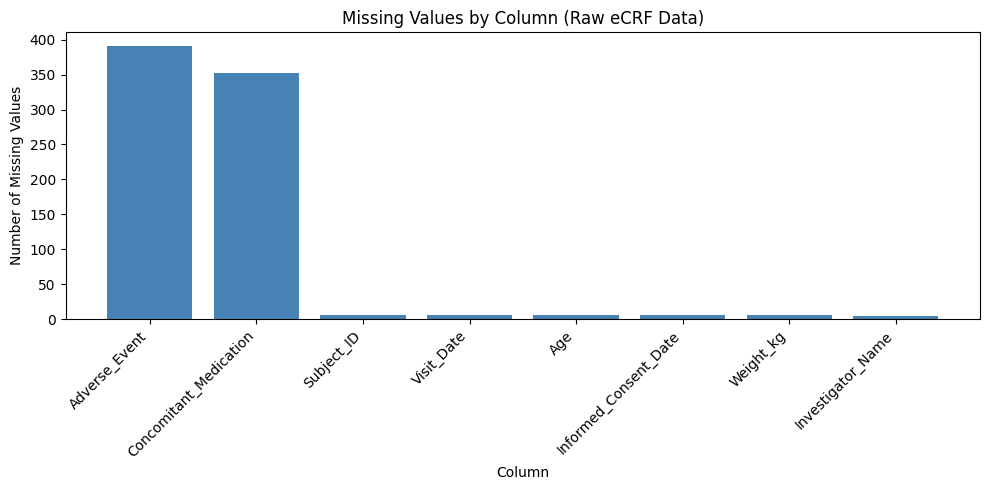

In [22]:
# Bar chart of missing values by column
plt.figure(figsize=(10, 5))
plt.bar(missing_summary.index, missing_summary["Missing_Count"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values by Column (Raw eCRF Data)")
plt.tight_layout()
plt.show()

### 13.2 Query Status Chart (Pie Chart) & Site-wise Query Chart (Bar Chart)

These two charts show how queries are distributed by status and by site.

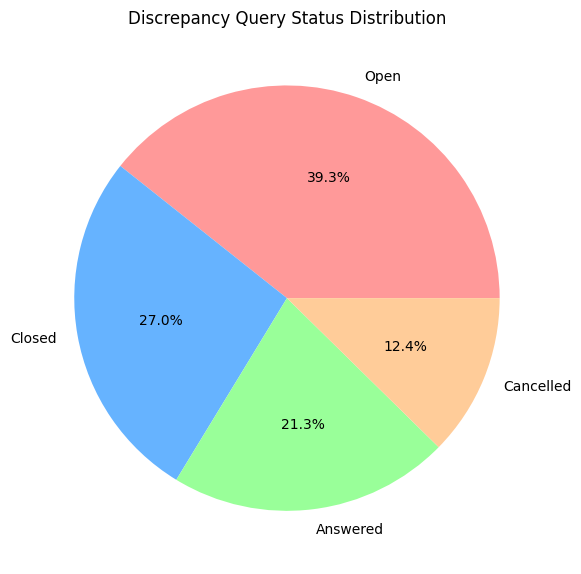

In [23]:
# Pie chart showing proportion of queries by status
plt.figure(figsize=(6, 6))
plt.pie(query_status_counts.values, labels=query_status_counts.index, autopct="%1.1f%%",
        colors=["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"])
plt.title("Discrepancy Query Status Distribution")
plt.tight_layout()
plt.show()

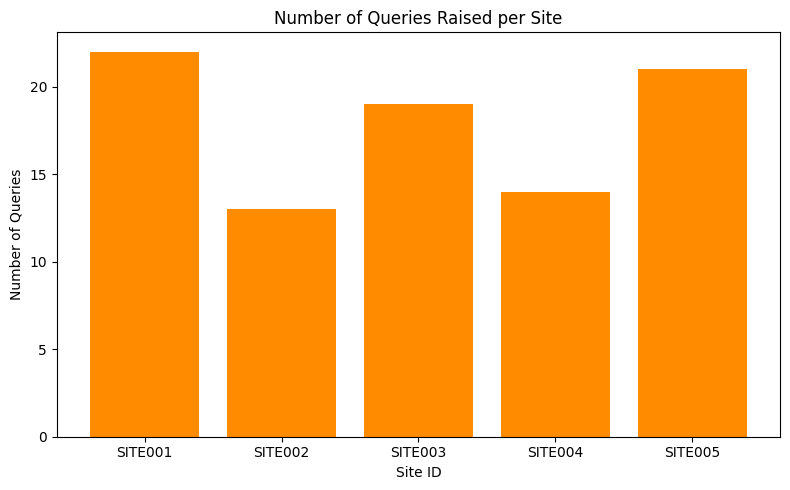

In [24]:
# Bar chart of number of queries raised per site
plt.figure(figsize=(8, 5))
plt.bar(site_query_counts.index, site_query_counts.values, color="darkorange")
plt.xlabel("Site ID")
plt.ylabel("Number of Queries")
plt.title("Number of Queries Raised per Site")
plt.tight_layout()
plt.show()

### 13.3 Subject-wise Query Count & Error Type Frequency (Bar Charts)

Next we look at which subjects generated the most queries, and which error
types occurred most often across the whole trial.

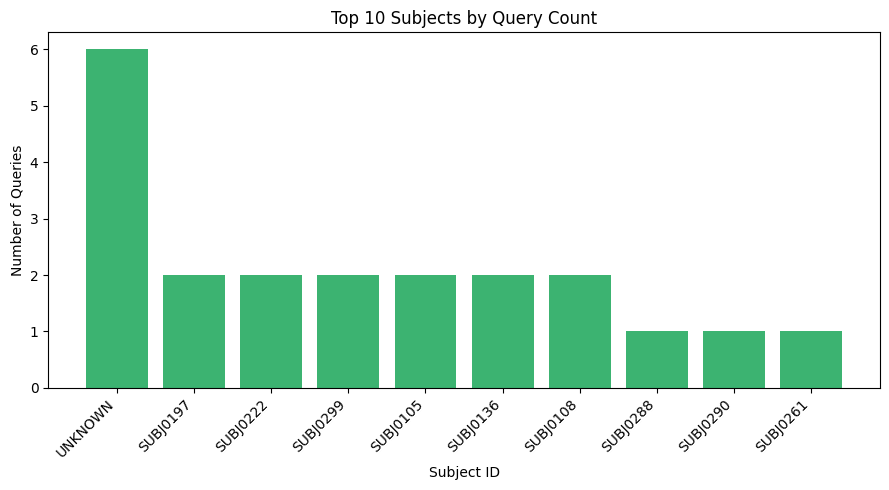

In [25]:
# Bar chart of the top 10 subjects by number of queries raised
top_subjects = query_df["Subject_ID"].value_counts().head(10)

plt.figure(figsize=(9, 5))
plt.bar(top_subjects.index, top_subjects.values, color="mediumseagreen")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Subject ID")
plt.ylabel("Number of Queries")
plt.title("Top 10 Subjects by Query Count")
plt.tight_layout()
plt.show()

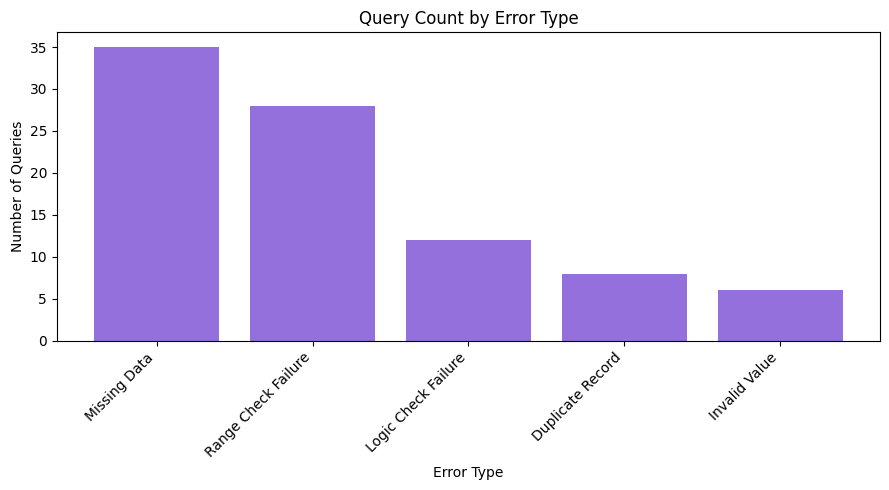

In [26]:
# Bar chart of query counts by error type
plt.figure(figsize=(9, 5))
plt.bar(error_frequency.index, error_frequency.values, color="mediumpurple")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Error Type")
plt.ylabel("Number of Queries")
plt.title("Query Count by Error Type")
plt.tight_layout()
plt.show()

### 13.4 Vital Sign & Age Distribution (Histograms)

Histograms help us understand the shape of continuous variables like heart
rate and age, and quickly spot values sitting outside the expected range.

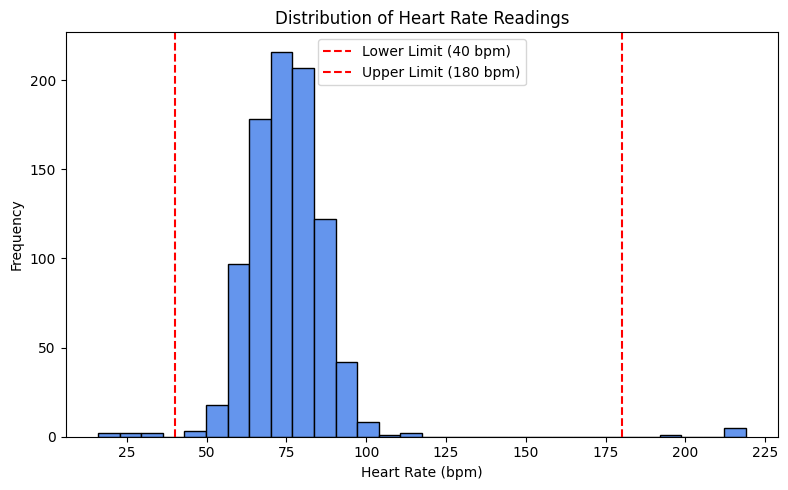

In [27]:
# Histogram of Heart Rate distribution across all visits
plt.figure(figsize=(8, 5))
plt.hist(raw_df["Heart_Rate_bpm"].dropna(), bins=30, color="cornflowerblue", edgecolor="black")
plt.axvline(40, color="red", linestyle="--", label="Lower Limit (40 bpm)")
plt.axvline(180, color="red", linestyle="--", label="Upper Limit (180 bpm)")
plt.xlabel("Heart Rate (bpm)")
plt.ylabel("Frequency")
plt.title("Distribution of Heart Rate Readings")
plt.legend()
plt.tight_layout()
plt.show()

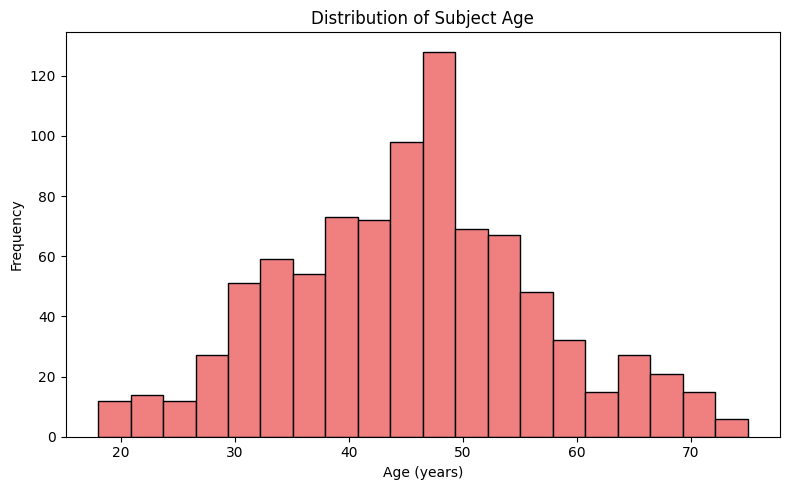

In [28]:
# Histogram of subject age distribution
plt.figure(figsize=(8, 5))
plt.hist(raw_df["Age"].dropna(), bins=20, color="lightcoral", edgecolor="black")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.title("Distribution of Subject Age")
plt.tight_layout()
plt.show()

### 13.5 Boxplot, Correlation Matrix & Records per Site

Finally, we use a boxplot to compare blood pressure readings, a correlation
heatmap to explore relationships between numeric variables, and a bar chart
of total records submitted per site.

/tmp/ipykernel_804/2111150052.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([raw_df["Systolic_BP_mmHg"].dropna(), raw_df["Diastolic_BP_mmHg"].dropna()],


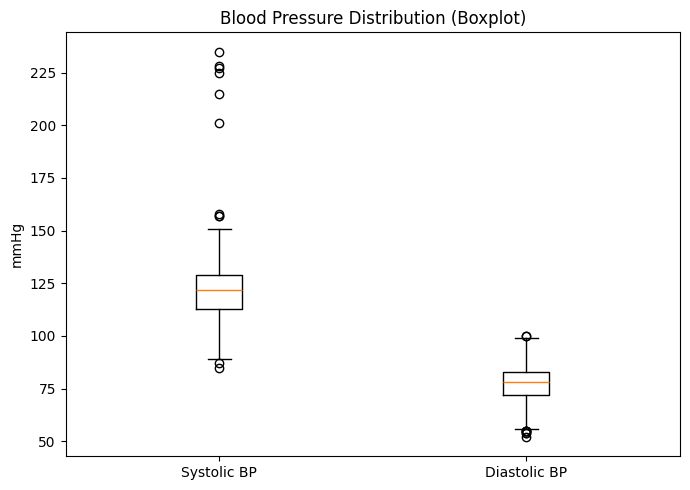

In [29]:
# Boxplot comparing systolic and diastolic blood pressure
plt.figure(figsize=(7, 5))
plt.boxplot([raw_df["Systolic_BP_mmHg"].dropna(), raw_df["Diastolic_BP_mmHg"].dropna()],
            labels=["Systolic BP", "Diastolic BP"])
plt.ylabel("mmHg")
plt.title("Blood Pressure Distribution (Boxplot)")
plt.tight_layout()
plt.show()

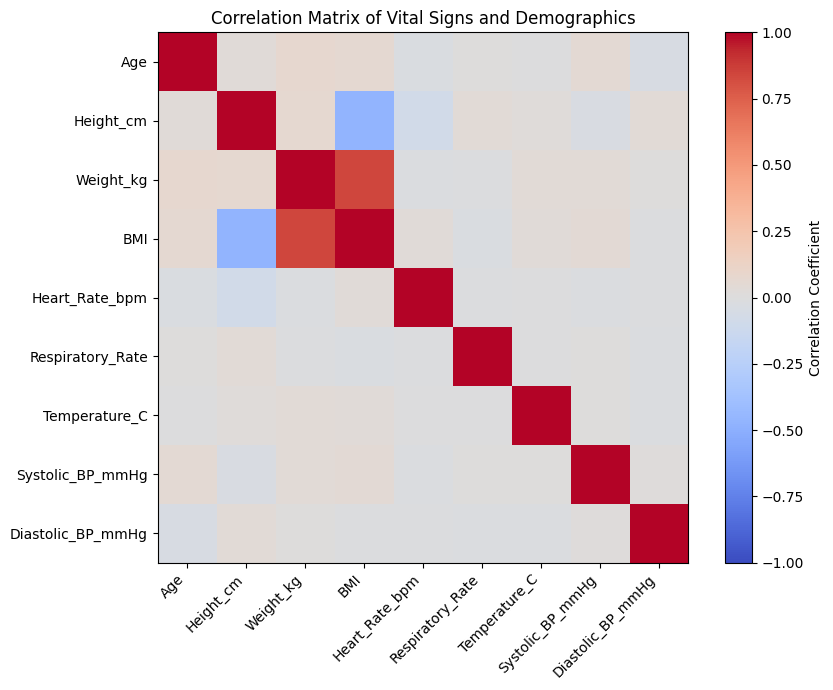

In [30]:
# Correlation matrix of key numeric vital sign columns
numeric_cols = ["Age", "Height_cm", "Weight_kg", "BMI", "Heart_Rate_bpm",
                "Respiratory_Rate", "Temperature_C", "Systolic_BP_mmHg", "Diastolic_BP_mmHg"]

correlation_matrix = raw_df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix of Vital Signs and Demographics")
plt.tight_layout()
plt.show()

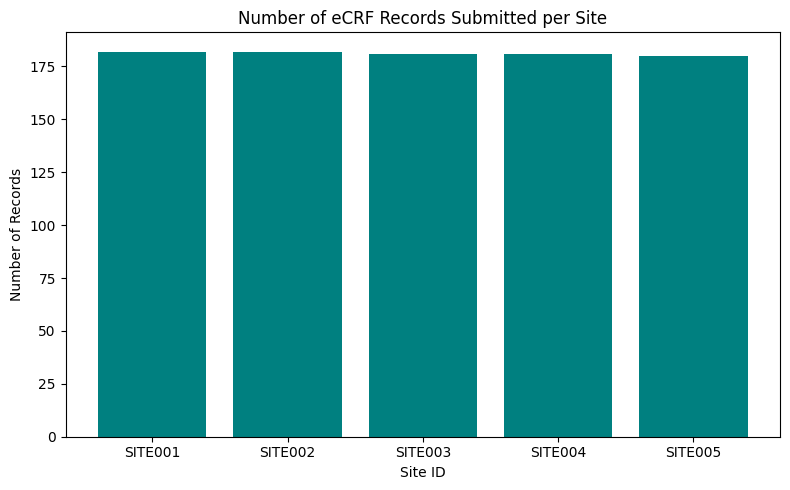

In [31]:
# Bar chart showing number of eCRF records submitted per site
plt.figure(figsize=(8, 5))
plt.bar(site_record_counts.index, site_record_counts.values, color="teal")
plt.xlabel("Site ID")
plt.ylabel("Number of Records")
plt.title("Number of eCRF Records Submitted per Site")
plt.tight_layout()
plt.show()

## 14. Final Data Quality Report

We now bring together the key metrics calculated throughout this notebook into
a single summary table. This mirrors the kind of Data Quality Report a Clinical
Data Coordinator would present to the study team before database lock.

In [32]:
# Build the final data quality summary table
total_records = len(raw_df)
total_queries = len(query_df)
open_queries = len(query_df[query_df["Query_Status"] == "Open"])
closed_queries = len(query_df[query_df["Query_Status"] == "Closed"])
error_rate = round((total_queries / total_records) * 100, 2)
total_missing_values = int(raw_df[core_columns].isnull().sum().sum())
protocol_deviations = len(visit_before_consent) + len(abnormal_hr) + len(abnormal_temp)

summary_data = {
    "Metric": [
        "Total Records",
        "Total Queries",
        "Open Queries",
        "Closed Queries",
        "Error Rate (%)",
        "Missing Values",
        "Protocol Deviations",
        "Overall Completeness (%)"
    ],
    "Value": [
        total_records,
        total_queries,
        open_queries,
        closed_queries,
        error_rate,
        total_missing_values,
        protocol_deviations,
        completeness_percent
    ]
}

final_summary_df = pd.DataFrame(summary_data)
final_summary_df

,Metric,Value
0,Total Records,906.00
1,Total Queries,89.00
2,Open Queries,35.00
3,Closed Queries,24.00
4,Error Rate (%),9.82
5,Missing Values,779.00
6,Protocol Deviations,28.00
7,Overall Completeness (%),95.91


In [33]:
# Save the final validation summary to the reports folder
final_summary_df.to_csv("../reports/validation_summary.csv", index=False)
print("Final validation summary saved to reports/validation_summary.csv")

Final validation summary saved to reports/validation_summary.csv


## 15. Recommendations

Based on the analysis performed in this notebook, the following recommendations
are proposed for the study team:

### Clinical Interpretation

- The dataset shows an overall completeness above 95%, which is broadly in line
  with acceptable industry standards, though missing **Subject ID**, **Visit
  Date**, and **Informed Consent Date** values are critical because they affect
  traceability and regulatory compliance.
- Out-of-range vital signs (extreme heart rate, blood pressure, and temperature
  values) may represent either genuine safety signals or data entry errors —
  these should always be confirmed with the site rather than silently corrected.
- A small number of **Visit Date before Consent Date** issues were identified;
  this is a serious protocol deviation type of finding, since subjects should
  never be assessed before signing informed consent.

### Data Quality Recommendations

1. Prioritize closure of **Open** and **Answered** queries at sites with the
   highest query volume, especially high-priority queries.
2. Provide targeted retraining to sites with lower completeness percentages,
   focusing on mandatory fields (Subject ID, Visit Date, Consent Date).
3. Implement real-time edit checks in the EDC system to catch out-of-range
   vital signs and invalid Sex values at the point of data entry.
4. Set up a recurring (e.g., weekly) query aging report so that older Open
   queries are escalated before database lock.
5. Reconcile duplicate Subject IDs and duplicate visit records promptly, as
   these can distort subject counts and statistical analysis.

### Future Work

- Automate this validation process into a reusable Python script that can be
  scheduled to run on each new eCRF data extract.
- Extend the query log to include an audit trail of query text exchanged
  between the Data Manager and the site.
- Build an interactive dashboard (e.g., in Power BI or Tableau) on top of the
  validation summary metrics for real-time monitoring during the trial.
- Add cross-form consistency checks (e.g., comparing lab dates against visit
  dates) once additional eCRF forms are available.

---
*This notebook is part of a synthetic, educational Clinical Data Management
portfolio project. No real patient data was used at any stage.*